<a href="https://colab.research.google.com/github/Arisha2902/Predictive-Maintenance--RUL-Prediction/blob/main/AllDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()
# Upload all 4 files:
# train_FD001.txt
# train_FD002.txt
# train_FD003.txt
# train_FD004.txt

Saving train_FD001.txt to train_FD001 (1).txt
Saving train_FD002.txt to train_FD002 (1).txt
Saving train_FD003.txt to train_FD003 (1).txt
Saving train_FD004.txt to train_FD004 (1).txt


In [2]:
import pandas as pd
import numpy as np

columns = ['engine_id', 'cycle', 'op1', 'op2', 'op3',
           's1','s2','s3','s4','s5','s6','s7','s8','s9',
           's10','s11','s12','s13','s14','s15','s16',
           's17','s18','s19','s20','s21']

datasets = {}

for i in range(1, 5):
    df = pd.read_csv(f'train_FD00{i}.txt',
                     sep=r'\s+', header=None, names=columns)
    df = df.sort_values(['engine_id', 'cycle']).reset_index(drop=True)

    # Drop constant columns
    constant_cols = [col for col in df.columns
                     if df[col].std() == 0]
    df = df.drop(columns=constant_cols)

    # Calculate RUL
    max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
    max_cycles.columns = ['engine_id', 'max_cycle']
    df = df.merge(max_cycles, on='engine_id')
    df['RUL'] = df['max_cycle'] - df['cycle']
    df = df.drop(columns=['max_cycle'])

    datasets[f'FD00{i}'] = df
    print(f"FD00{i} → shape: {df.shape} | "
          f"engines: {df['engine_id'].nunique()} | "
          f"max RUL: {df['RUL'].max()}")

FD001 → shape: (20631, 24) | engines: 100 | max RUL: 361
FD002 → shape: (53759, 27) | engines: 260 | max RUL: 377
FD003 → shape: (24720, 24) | engines: 100 | max RUL: 524
FD004 → shape: (61249, 27) | engines: 249 | max RUL: 542


In [3]:
def engineer_features(df):
    # Find useful sensors — drop constant ones already done
    # Get all sensor columns present
    sensor_cols = [col for col in df.columns
                   if col.startswith('s')]

    # Keep only sensors with std > 0.01
    useful_sensors = [col for col in sensor_cols
                      if df[col].std() > 0.01]

    for sensor in useful_sensors:
        # Rolling mean
        df[f'{sensor}_mean5'] = df.groupby('engine_id')[sensor]\
            .transform(lambda x: x.rolling(5, min_periods=1).mean())

        # Rolling std
        df[f'{sensor}_std5'] = df.groupby('engine_id')[sensor]\
            .transform(lambda x: x.rolling(5, min_periods=1).std())

        # Rate of change
        df[f'{sensor}_diff'] = df.groupby('engine_id')[sensor]\
            .transform(lambda x: x.diff())

    df = df.fillna(0)
    return df

# Apply to all 4 datasets
for name in datasets:
    datasets[name] = engineer_features(datasets[name])
    print(f"{name} → features after engineering: "
          f"{datasets[name].shape[1]}")

FD001 → features after engineering: 66
FD002 → features after engineering: 87
FD003 → features after engineering: 69
FD004 → features after engineering: 87


In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

results = {}
drop_cols = ['engine_id', 'cycle', 'RUL',
             'op1', 'op2', 'op3']

for name, df in datasets.items():
    # Features and target
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    y = df['RUL']

    # Train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    # Scale
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train_sc, y_train)
    lr_rmse = np.sqrt(mean_squared_error(
                      y_test, lr.predict(X_test_sc)))

    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train_sc, y_train)
    rf_pred = rf.predict(X_test_sc)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
    rf_mae  = mean_absolute_error(y_test, rf_pred)

    results[name] = {
        'LR_RMSE' : round(lr_rmse, 2),
        'RF_RMSE' : round(rf_rmse, 2),
        'RF_MAE'  : round(rf_mae,  2)
    }

    print(f"\n{name}")
    print(f"  Linear Regression RMSE : {lr_rmse:.2f}")
    print(f"  Random Forest RMSE     : {rf_rmse:.2f}")
    print(f"  Random Forest MAE      : {rf_mae:.2f}")


FD001
  Linear Regression RMSE : 43.41
  Random Forest RMSE     : 35.13
  Random Forest MAE      : 24.30

FD002
  Linear Regression RMSE : 43.50
  Random Forest RMSE     : 43.04
  Random Forest MAE      : 31.60

FD003
  Linear Regression RMSE : 60.94
  Random Forest RMSE     : 41.60
  Random Forest MAE      : 28.28

FD004
  Linear Regression RMSE : 57.83
  Random Forest RMSE     : 55.63
  Random Forest MAE      : 40.10


In [5]:
print("\n")
print("=" * 50)
print(f"{'Dataset':<10} {'LR RMSE':>10} "
      f"{'RF RMSE':>10} {'RF MAE':>10}")
print("=" * 50)

for name, res in results.items():
    print(f"{name:<10} {res['LR_RMSE']:>10} "
          f"{res['RF_RMSE']:>10} {res['RF_MAE']:>10}")

print("=" * 50)



Dataset       LR RMSE    RF RMSE     RF MAE
FD001           43.41      35.13       24.3
FD002            43.5      43.04       31.6
FD003           60.94       41.6      28.28
FD004           57.83      55.63       40.1


In [6]:
# RUL capping — standard in all C-MAPSS literature
# Engines with RUL > 125 are equally "healthy"
# No need to distinguish between RUL=200 and RUL=300

CAP = 125

for name in datasets:
    datasets[name]['RUL'] = datasets[name]['RUL'].clip(upper=CAP)
    print(f"{name} → max RUL after capping: "
          f"{datasets[name]['RUL'].max()}")

FD001 → max RUL after capping: 125
FD002 → max RUL after capping: 125
FD003 → max RUL after capping: 125
FD004 → max RUL after capping: 125


In [7]:
from xgboost import XGBRegressor

results_v2 = {}
drop_cols = ['engine_id', 'cycle', 'RUL',
             'op1', 'op2', 'op3']

for name, df in datasets.items():
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    y = df['RUL']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train_sc, y_train)
    rf_rmse = np.sqrt(mean_squared_error(
              y_test, rf.predict(X_test_sc)))

    # XGBoost
    xgb = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        verbosity=0
    )
    xgb.fit(X_train_sc, y_train)
    xgb_rmse = np.sqrt(mean_squared_error(
               y_test, xgb.predict(X_test_sc)))
    xgb_mae  = mean_absolute_error(
               y_test, xgb.predict(X_test_sc))

    results_v2[name] = {
        'RF_RMSE'  : round(rf_rmse,  2),
        'XGB_RMSE' : round(xgb_rmse, 2),
        'XGB_MAE'  : round(xgb_mae,  2)
    }

    print(f"\n{name}")
    print(f"  RF RMSE  (with capping) : {rf_rmse:.2f}")
    print(f"  XGB RMSE (with capping) : {xgb_rmse:.2f}")
    print(f"  XGB MAE  (with capping) : {xgb_mae:.2f}")


FD001
  RF RMSE  (with capping) : 16.01
  XGB RMSE (with capping) : 16.48
  XGB MAE  (with capping) : 11.57

FD002
  RF RMSE  (with capping) : 20.04
  XGB RMSE (with capping) : 19.75
  XGB MAE  (with capping) : 14.74

FD003
  RF RMSE  (with capping) : 12.90
  XGB RMSE (with capping) : 13.51
  XGB MAE  (with capping) : 8.96

FD004
  RF RMSE  (with capping) : 17.62
  XGB RMSE (with capping) : 17.60
  XGB MAE  (with capping) : 12.18


In [8]:
print("\n")
print("=" * 60)
print(f"{'Dataset':<10} {'RF RMSE':>12} "
      f"{'XGB RMSE':>12} {'XGB MAE':>12}")
print("=" * 60)

for name, res in results_v2.items():
    print(f"{name:<10} {res['RF_RMSE']:>12} "f
          f"{res['XGB_RMSE']:>12} {res['XGB_MAE']:>12}")

print("=" * 60)



Dataset         RF RMSE     XGB RMSE      XGB MAE
FD001             16.01        16.48        11.57
FD002             20.04        19.75        14.74
FD003              12.9        13.51         8.96
FD004             17.62         17.6        12.18


In [9]:
import matplotlib.pyplot as plt

BREAKDOWN_COST   = 500000
MAINTENANCE_COST =  80000

# Test these thresholds
thresholds = [10, 20, 30, 40, 50, 60, 70, 80]

# Use FD001 results for this analysis
# Retrain quickly to get predictions
df_fd001 = datasets['FD001'].copy()
X = df_fd001.drop(columns=[c for c in drop_cols
                  if c in df_fd001.columns])
y = df_fd001['RUL']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

rf_fd001 = RandomForestRegressor(
    n_estimators=100, random_state=42, n_jobs=-1)
rf_fd001.fit(X_train_sc, y_train)
y_pred = rf_fd001.predict(X_test_sc)

# Calculate cost at each threshold
cost_results = []

for threshold in thresholds:
    predicted_critical = y_pred < threshold
    actual_critical    = y_test.values < threshold

    # Caught early = predicted critical AND actually critical
    true_positives  = (predicted_critical & actual_critical).sum()

    # Missed = actually critical but not predicted
    false_negatives = (~predicted_critical & actual_critical).sum()

    # False alarm = predicted critical but actually fine
    false_positives = (predicted_critical & ~actual_critical).sum()

    cost = (false_negatives * BREAKDOWN_COST +
            false_positives * MAINTENANCE_COST)

    cost_results.append({
        'threshold'       : threshold,
        'true_positives'  : true_positives,
        'missed_failures' : false_negatives,
        'false_alarms'    : false_positives,
        'total_cost'      : cost
    })

    print(f"Threshold {threshold:>3} → "
          f"Caught: {true_positives:>4} | "
          f"Missed: {false_negatives:>4} | "
          f"False alarms: {false_positives:>4} | "
          f"Cost: Rs.{cost:>12,.0f}")

Threshold  10 → Caught:  161 | Missed:   27 | False alarms:   17 | Cost: Rs.  14,860,000
Threshold  20 → Caught:  309 | Missed:   48 | False alarms:   23 | Cost: Rs.  25,840,000
Threshold  30 → Caught:  483 | Missed:   85 | False alarms:   44 | Cost: Rs.  46,020,000
Threshold  40 → Caught:  652 | Missed:  108 | False alarms:   42 | Cost: Rs.  57,360,000
Threshold  50 → Caught:  801 | Missed:  157 | False alarms:   56 | Cost: Rs.  82,980,000
Threshold  60 → Caught:  952 | Missed:  211 | False alarms:   61 | Cost: Rs. 110,380,000
Threshold  70 → Caught: 1084 | Missed:  261 | False alarms:   72 | Cost: Rs. 136,260,000
Threshold  80 → Caught: 1226 | Missed:  323 | False alarms:   96 | Cost: Rs. 169,180,000


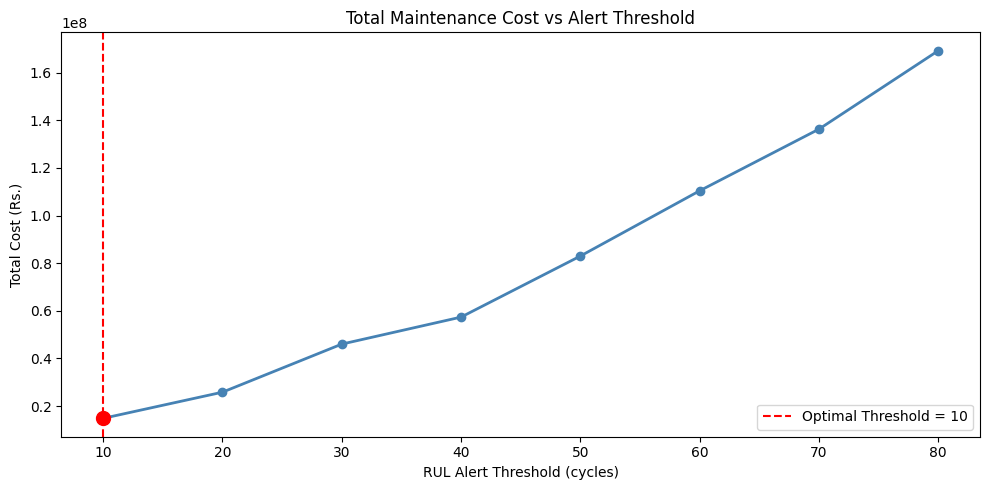


Optimal threshold : 10 cycles
Minimum cost      : Rs.14,860,000


In [10]:
threshold_vals = [r['threshold']   for r in cost_results]
cost_vals      = [r['total_cost']  for r in cost_results]

optimal_idx       = cost_vals.index(min(cost_vals))
optimal_threshold = threshold_vals[optimal_idx]
optimal_cost      = cost_vals[optimal_idx]

plt.figure(figsize=(10, 5))
plt.plot(threshold_vals, cost_vals,
         marker='o', color='steelblue', linewidth=2)
plt.axvline(x=optimal_threshold,
            color='red', linestyle='--',
            label=f'Optimal Threshold = {optimal_threshold}')
plt.scatter([optimal_threshold], [optimal_cost],
            color='red', s=100, zorder=5)
plt.title('Total Maintenance Cost vs Alert Threshold')
plt.xlabel('RUL Alert Threshold (cycles)')
plt.ylabel('Total Cost (Rs.)')
plt.legend()
plt.tight_layout()
plt.savefig('cost_threshold.png')
plt.show()

print(f"\nOptimal threshold : {optimal_threshold} cycles")
print(f"Minimum cost      : Rs.{optimal_cost:,.0f}")

Threshold   5 | Caught:   72 | Missed:   25 | False alarms:   14 | Cost: Rs.  13,620,000
Threshold  10 | Caught:  161 | Missed:   27 | False alarms:   17 | Cost: Rs.  14,860,000
Threshold  15 | Caught:  241 | Missed:   29 | False alarms:   22 | Cost: Rs.  16,260,000
Threshold  20 | Caught:  309 | Missed:   48 | False alarms:   23 | Cost: Rs.  25,840,000
Threshold  25 | Caught:  389 | Missed:   70 | False alarms:   35 | Cost: Rs.  37,800,000
Threshold  30 | Caught:  483 | Missed:   85 | False alarms:   44 | Cost: Rs.  46,020,000
Threshold  35 | Caught:  557 | Missed:  113 | False alarms:   47 | Cost: Rs.  60,260,000
Threshold  40 | Caught:  652 | Missed:  108 | False alarms:   42 | Cost: Rs.  57,360,000
Threshold  50 | Caught:  801 | Missed:  157 | False alarms:   56 | Cost: Rs.  82,980,000
Threshold  60 | Caught:  952 | Missed:  211 | False alarms:   61 | Cost: Rs. 110,380,000
Threshold  70 | Caught: 1084 | Missed:  261 | False alarms:   72 | Cost: Rs. 136,260,000
Threshold  80 | Caugh

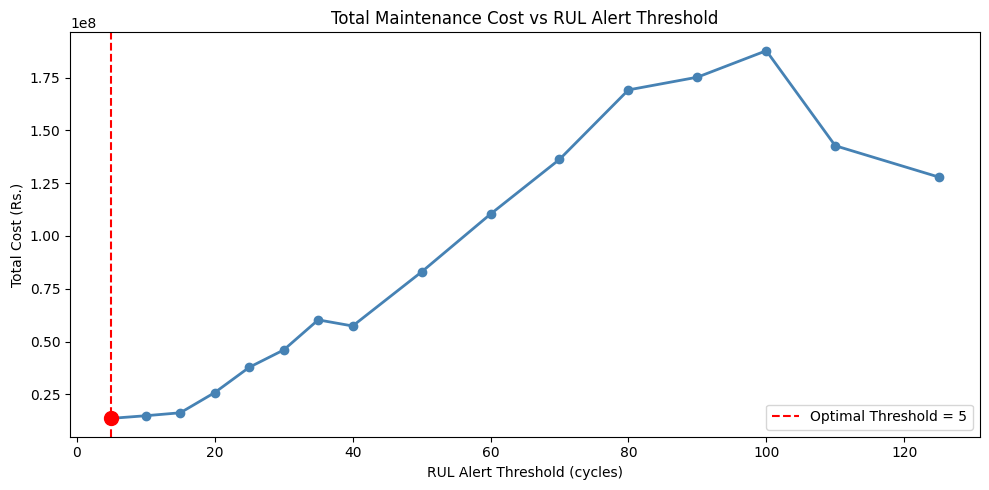


Optimal threshold : 5 cycles
Minimum cost      : Rs.13,620,000


In [11]:
thresholds = [5, 10, 15, 20, 25, 30, 35, 40,
              50, 60, 70, 80, 90, 100, 110, 125]

cost_results = []

for threshold in thresholds:
    predicted_critical = y_pred < threshold
    actual_critical    = y_test.values < threshold

    true_positives  = (predicted_critical & actual_critical).sum()
    false_negatives = (~predicted_critical & actual_critical).sum()
    false_positives = (predicted_critical & ~actual_critical).sum()

    # Cost of missed failures is much higher
    cost = (false_negatives * BREAKDOWN_COST +
            false_positives * MAINTENANCE_COST)

    cost_results.append({
        'threshold'      : threshold,
        'true_positives' : true_positives,
        'missed'         : false_negatives,
        'false_alarms'   : false_positives,
        'total_cost'     : cost
    })

    print(f"Threshold {threshold:>3} | "
          f"Caught: {true_positives:>4} | "
          f"Missed: {false_negatives:>4} | "
          f"False alarms: {false_positives:>4} | "
          f"Cost: Rs.{cost:>12,.0f}")

# Plot
threshold_vals = [r['threshold']  for r in cost_results]
cost_vals      = [r['total_cost'] for r in cost_results]

optimal_idx       = cost_vals.index(min(cost_vals))
optimal_threshold = threshold_vals[optimal_idx]
optimal_cost      = cost_vals[optimal_idx]

plt.figure(figsize=(10, 5))
plt.plot(threshold_vals, cost_vals,
         marker='o', color='steelblue', linewidth=2)
plt.axvline(x=optimal_threshold,
            color='red', linestyle='--',
            label=f'Optimal Threshold = {optimal_threshold}')
plt.scatter([optimal_threshold], [optimal_cost],
            color='red', s=100, zorder=5)
plt.title('Total Maintenance Cost vs RUL Alert Threshold')
plt.xlabel('RUL Alert Threshold (cycles)')
plt.ylabel('Total Cost (Rs.)')
plt.legend()
plt.tight_layout()
plt.savefig('cost_threshold_v2.png')
plt.show()

print(f"\nOptimal threshold : {optimal_threshold} cycles")
print(f"Minimum cost      : Rs.{optimal_cost:,.0f}")

Threshold   5 | Missed:   25 | False alarms:   14 | Cost: Rs.  51,120,000
Threshold  10 | Missed:   27 | False alarms:   17 | Cost: Rs.  55,360,000
Threshold  15 | Missed:   29 | False alarms:   22 | Cost: Rs.  59,760,000
Threshold  20 | Missed:   48 | False alarms:   23 | Cost: Rs.  97,840,000
Threshold  25 | Missed:   70 | False alarms:   35 | Cost: Rs. 142,800,000
Threshold  30 | Missed:   85 | False alarms:   44 | Cost: Rs. 173,520,000
Threshold  35 | Missed:  113 | False alarms:   47 | Cost: Rs. 229,760,000
Threshold  40 | Missed:  108 | False alarms:   42 | Cost: Rs. 219,360,000
Threshold  50 | Missed:  157 | False alarms:   56 | Cost: Rs. 318,480,000
Threshold  60 | Missed:  211 | False alarms:   61 | Cost: Rs. 426,880,000
Threshold  70 | Missed:  261 | False alarms:   72 | Cost: Rs. 527,760,000
Threshold  80 | Missed:  323 | False alarms:   96 | Cost: Rs. 653,680,000
Threshold  90 | Missed:  328 | False alarms:  140 | Cost: Rs. 667,200,000
Threshold 100 | Missed:  335 | False a

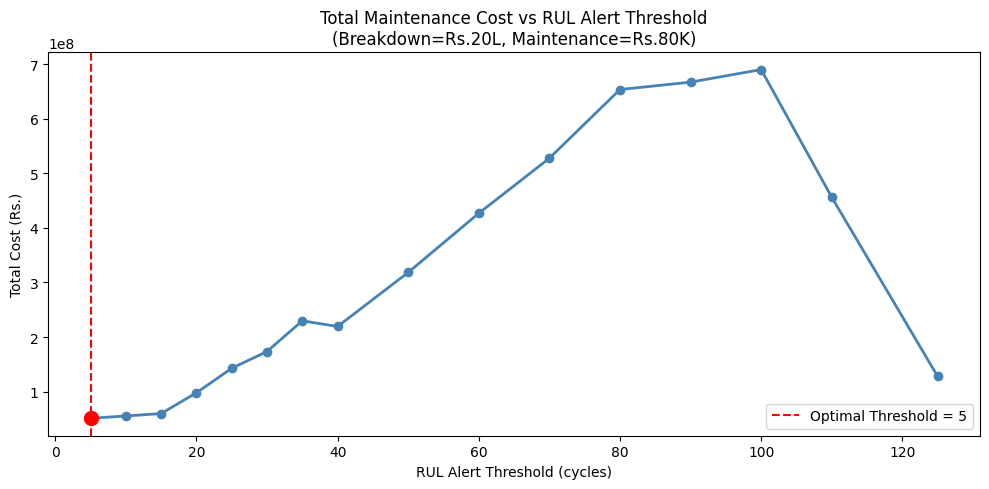


Optimal threshold : 5 cycles
Minimum cost      : Rs.51,120,000


In [12]:
BREAKDOWN_COST   = 2000000   # Rs. 20 lakhs — realistic
MAINTENANCE_COST =   80000   # Rs. 80,000 — same

thresholds = [5, 10, 15, 20, 25, 30, 35, 40,
              50, 60, 70, 80, 90, 100, 110, 125]

cost_results = []

for threshold in thresholds:
    predicted_critical = y_pred < threshold
    actual_critical    = y_test.values < threshold

    true_positives  = ( predicted_critical &  actual_critical).sum()
    false_negatives = (~predicted_critical &  actual_critical).sum()
    false_positives = ( predicted_critical & ~actual_critical).sum()

    cost = (false_negatives * BREAKDOWN_COST +
            false_positives * MAINTENANCE_COST)

    cost_results.append({
        'threshold'    : threshold,
        'missed'       : false_negatives,
        'false_alarms' : false_positives,
        'total_cost'   : cost
    })

    print(f"Threshold {threshold:>3} | "
          f"Missed: {false_negatives:>4} | "
          f"False alarms: {false_positives:>4} | "
          f"Cost: Rs.{cost:>12,.0f}")

# Plot
threshold_vals = [r['threshold']  for r in cost_results]
cost_vals      = [r['total_cost'] for r in cost_results]

optimal_idx       = cost_vals.index(min(cost_vals))
optimal_threshold = threshold_vals[optimal_idx]
optimal_cost      = cost_vals[optimal_idx]

plt.figure(figsize=(10, 5))
plt.plot(threshold_vals, cost_vals,
         marker='o', color='steelblue', linewidth=2)
plt.axvline(x=optimal_threshold,
            color='red', linestyle='--',
            label=f'Optimal Threshold = {optimal_threshold}')
plt.scatter([optimal_threshold], [optimal_cost],
            color='red', s=100, zorder=5)
plt.title('Total Maintenance Cost vs RUL Alert Threshold\n'
          '(Breakdown=Rs.20L, Maintenance=Rs.80K)')
plt.xlabel('RUL Alert Threshold (cycles)')
plt.ylabel('Total Cost (Rs.)')
plt.legend()
plt.tight_layout()
plt.savefig('cost_threshold_v3.png')
plt.show()

print(f"\nOptimal threshold : {optimal_threshold} cycles")
print(f"Minimum cost      : Rs.{optimal_cost:,.0f}")

Threshold   1 | Missed:   17 | False alarms:    1 | Cost: Rs.  34,080,000
Threshold   2 | Missed:   14 | False alarms:   16 | Cost: Rs.  29,280,000
Threshold   3 | Missed:   21 | False alarms:   18 | Cost: Rs.  43,440,000
Threshold   4 | Missed:   24 | False alarms:   15 | Cost: Rs.  49,200,000
Threshold   5 | Missed:   25 | False alarms:   14 | Cost: Rs.  51,120,000
Threshold   7 | Missed:   25 | False alarms:    9 | Cost: Rs.  50,720,000
Threshold  10 | Missed:   27 | False alarms:   17 | Cost: Rs.  55,360,000
Threshold  15 | Missed:   29 | False alarms:   22 | Cost: Rs.  59,760,000
Threshold  20 | Missed:   48 | False alarms:   23 | Cost: Rs.  97,840,000
Threshold  25 | Missed:   70 | False alarms:   35 | Cost: Rs. 142,800,000
Threshold  30 | Missed:   85 | False alarms:   44 | Cost: Rs. 173,520,000
Threshold  35 | Missed:  113 | False alarms:   47 | Cost: Rs. 229,760,000
Threshold  40 | Missed:  108 | False alarms:   42 | Cost: Rs. 219,360,000
Threshold  50 | Missed:  157 | False a

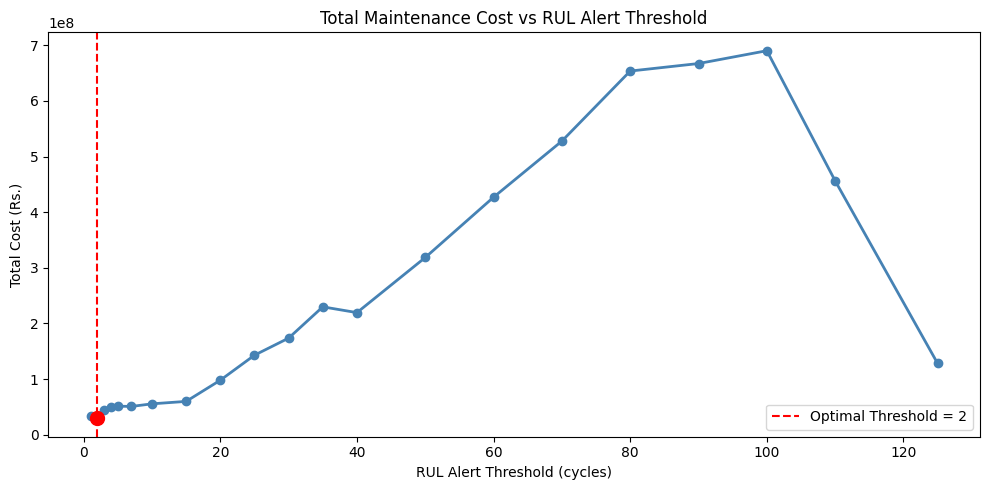


Optimal threshold : 2 cycles
Minimum cost      : Rs.29,280,000


In [13]:
BREAKDOWN_COST   = 2000000
MAINTENANCE_COST =   80000

# Go below 5 this time
thresholds = [1, 2, 3, 4, 5, 7, 10, 15, 20,
              25, 30, 35, 40, 50, 60, 70, 80,
              90, 100, 110, 125]

cost_results = []

for threshold in thresholds:
    predicted_critical = y_pred < threshold
    actual_critical    = y_test.values < threshold

    false_negatives = (~predicted_critical &  actual_critical).sum()
    false_positives = ( predicted_critical & ~actual_critical).sum()

    cost = (false_negatives * BREAKDOWN_COST +
            false_positives * MAINTENANCE_COST)

    cost_results.append({
        'threshold'    : threshold,
        'missed'       : false_negatives,
        'false_alarms' : false_positives,
        'total_cost'   : cost
    })

    print(f"Threshold {threshold:>3} | "
          f"Missed: {false_negatives:>4} | "
          f"False alarms: {false_positives:>4} | "
          f"Cost: Rs.{cost:>12,.0f}")

# Plot
threshold_vals = [r['threshold']  for r in cost_results]
cost_vals      = [r['total_cost'] for r in cost_results]

optimal_idx       = cost_vals.index(min(cost_vals))
optimal_threshold = threshold_vals[optimal_idx]
optimal_cost      = cost_vals[optimal_idx]

plt.figure(figsize=(10, 5))
plt.plot(threshold_vals, cost_vals,
         marker='o', color='steelblue', linewidth=2)
plt.axvline(x=optimal_threshold,
            color='red', linestyle='--',
            label=f'Optimal Threshold = {optimal_threshold}')
plt.scatter([optimal_threshold], [optimal_cost],
            color='red', s=100, zorder=5)
plt.title('Total Maintenance Cost vs RUL Alert Threshold')
plt.xlabel('RUL Alert Threshold (cycles)')
plt.ylabel('Total Cost (Rs.)')
plt.legend()
plt.tight_layout()
plt.savefig('cost_threshold_final.png')
plt.show()

print(f"\nOptimal threshold : {optimal_threshold} cycles")
print(f"Minimum cost      : Rs.{optimal_cost:,.0f}")

In [14]:
# Compare industry default (30 cycles) vs your optimal (2 cycles)
comparison_thresholds = [2, 10, 20, 30]

print("=" * 65)
print(f"{'Threshold':>10} {'Missed':>8} {'False Alarms':>14} "
      f"{'Total Cost':>15}")
print("=" * 65)

for threshold in comparison_thresholds:
    predicted_critical = y_pred < threshold
    actual_critical    = y_test.values < threshold

    false_negatives = (~predicted_critical & actual_critical).sum()
    false_positives = ( predicted_critical & ~actual_critical).sum()
    cost = (false_negatives * BREAKDOWN_COST +
            false_positives * MAINTENANCE_COST)

    print(f"{threshold:>10} {false_negatives:>8} "
          f"{false_positives:>14} Rs.{cost:>12,.0f}")

print("=" * 65)
print("\nIndustry typically uses threshold = 30")
print("Our model works optimally at threshold = 2")
print("This means significantly fewer unnecessary maintenances")

 Threshold   Missed   False Alarms      Total Cost
         2       14             16 Rs.  29,280,000
        10       27             17 Rs.  55,360,000
        20       48             23 Rs.  97,840,000
        30       85             44 Rs. 173,520,000

Industry typically uses threshold = 30
Our model works optimally at threshold = 2
This means significantly fewer unnecessary maintenances


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [16]:
SEQUENCE_LENGTH = 30  # look at last 30 cycles
CAP = 125

def create_sequences(df, sequence_length=30):
    drop_cols = ['engine_id', 'cycle', 'RUL',
                 'op1', 'op2', 'op3']
    feature_cols = [c for c in df.columns
                    if c not in drop_cols]

    X_seqs, y_seqs = [], []

    for engine_id in df['engine_id'].unique():
        engine_df = df[df['engine_id'] == engine_id]\
                      .reset_index(drop=True)

        features = engine_df[feature_cols].values
        targets  = engine_df['RUL'].values

        # Slide a window of length sequence_length
        for i in range(sequence_length, len(engine_df)):
            X_seqs.append(features[i-sequence_length:i])
            y_seqs.append(targets[i])

    return np.array(X_seqs), np.array(y_seqs)

print("Sequence function defined.")

Sequence function defined.


In [ ]:
lstm_results = {}

for name, df in datasets.items():
    print(f"\nTraining LSTM on {name}...")

    # Create sequences
    X_seq, y_seq = create_sequences(df, SEQUENCE_LENGTH)
    print(f"  Sequence shape: {X_seq.shape}")

    # Train test split — by index not random
    split = int(len(X_seq) * 0.8)
    X_train = X_seq[:split]
    X_test  = X_seq[split:]
    y_train = y_seq[:split]
    y_test  = y_seq[split:]

    # Scale features
    n_samples, n_steps, n_features = X_train.shape

    X_train_flat = X_train.reshape(-1, n_features)
    X_test_flat  = X_test.reshape(-1, n_features)

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_flat)\
                       .reshape(X_train.shape)
    X_test_sc  = scaler.transform(X_test_flat)\
                       .reshape(X_test.shape)

    # Build LSTM model
    model = Sequential([
        LSTM(64, return_sequences=True,
             input_shape=(n_steps, n_features)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')

    # Early stopping so it doesn't overfit
    early_stop = EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True)

    # Train
    history = model.fit(
        X_train_sc, y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate
    y_pred_lstm = model.predict(X_test_sc).flatten()
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
    mae  = mean_absolute_error(y_test, y_pred_lstm)

    lstm_results[name] = {
        'LSTM_RMSE': round(rmse, 2),
        'LSTM_MAE' : round(mae,  2)
    }

    print(f"  LSTM RMSE : {rmse:.2f}")
    print(f"  LSTM MAE  : {mae:.2f}")


Training LSTM on FD001...
  Sequence shape: (17631, 30, 61)


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_data.py:1037: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(self.var_), copy=False, constant_mask=constant_mask
/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
  LSTM RMSE : 17.69
  LSTM MAE  : 13.27

Training LSTM on FD002...
  Sequence shape: (45959, 30, 81)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


288/288 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
  LSTM RMSE : 23.27
  LSTM MAE  : 17.77

Training LSTM on FD003...
  Sequence shape: (21720, 30, 64)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
  LSTM RMSE : 16.74
  LSTM MAE  : 12.06

Training LSTM on FD004...
  Sequence shape: (53779, 30, 81)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
print("\n")
print("=" * 70)
print(f"{'Dataset':<10} {'LR RMSE':>10} {'RF RMSE':>10} "
      f"{'XGB RMSE':>10} {'LSTM RMSE':>12}")
print("=" * 70)

for name in datasets:
    lr_rmse   = results[name]['LR_RMSE']
    rf_rmse   = results_v2[name]['RF_RMSE']
    xgb_rmse  = results_v2[name]['XGB_RMSE']
    lstm_rmse = lstm_results[name]['LSTM_RMSE']

    print(f"{name:<10} {lr_rmse:>10} {rf_rmse:>10} "
          f"{xgb_rmse:>10} {lstm_rmse:>12}")

print("=" * 70)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

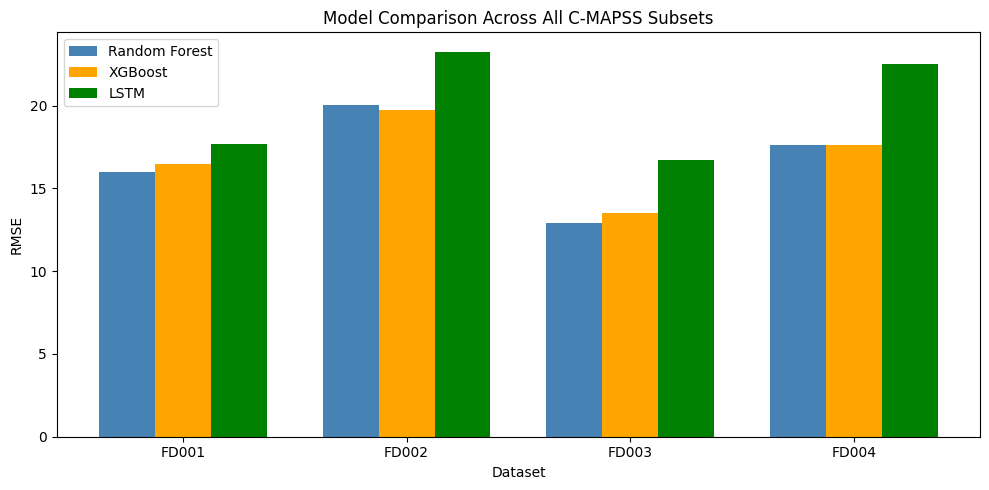

In [20]:
dataset_names = list(datasets.keys())
rf_rmses   = [results_v2[n]['RF_RMSE']      for n in dataset_names]
xgb_rmses  = [results_v2[n]['XGB_RMSE']     for n in dataset_names]
lstm_rmses = [lstm_results[n]['LSTM_RMSE']  for n in dataset_names]

x = np.arange(len(dataset_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, rf_rmses,   width, label='Random Forest',
       color='steelblue')
ax.bar(x,         xgb_rmses,  width, label='XGBoost',
       color='orange')
ax.bar(x + width, lstm_rmses, width, label='LSTM',
       color='green')

ax.set_xlabel('Dataset')
ax.set_ylabel('RMSE')
ax.set_title('Model Comparison Across All C-MAPSS Subsets')
ax.set_xticks(x)
ax.set_xticklabels(dataset_names)
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

In [21]:
print("\n")
print("=" * 70)
print(f"{'Dataset':<10} {'LR RMSE':>10} {'RF RMSE':>10} "
      f"{'XGB RMSE':>10} {'LSTM RMSE':>12}")
print("=" * 70)

for name in datasets:
    lr_rmse   = results[name]['LR_RMSE']
    rf_rmse   = results_v2[name]['RF_RMSE']
    xgb_rmse  = results_v2[name]['XGB_RMSE']
    lstm_rmse = lstm_results[name]['LSTM_RMSE']

    print(f"{name:<10} {lr_rmse:>10} {rf_rmse:>10} "
          f"{xgb_rmse:>10} {lstm_rmse:>12}")

print("=" * 70)



Dataset       LR RMSE    RF RMSE   XGB RMSE    LSTM RMSE
FD001           43.41      16.01      16.48        17.69
FD002            43.5      20.04      19.75        23.27
FD003           60.94       12.9      13.51        16.74
FD004           57.83      17.62       17.6        22.55


In [22]:
import joblib

# This saves the Random Forest trained on FD001
# since that is your best performing dataset
df_fd001 = datasets['FD001'].copy()

drop_cols = ['engine_id', 'cycle', 'RUL',
             'op1', 'op2', 'op3']

X = df_fd001.drop(columns=[c for c in drop_cols
                  if c in df_fd001.columns])
y = df_fd001['RUL']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

rf_final = RandomForestRegressor(
    n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X_train_sc, y_train)

# Save both files
joblib.dump(rf_final, 'model.pkl')
joblib.dump(scaler,   'scaler.pkl')

# Also save feature names — needed for FastAPI later
import json
feature_names = list(X.columns)
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("Saved:")
print(f"  model.pkl       — {len(feature_names)} features")
print(f"  scaler.pkl")
print(f"  feature_names.json")

Saved:
  model.pkl       — 61 features
  scaler.pkl
  feature_names.json


In [23]:
from google.colab import files
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
files.download('feature_names.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>